✅ SUCCESS: 2 hands labeled correctly.


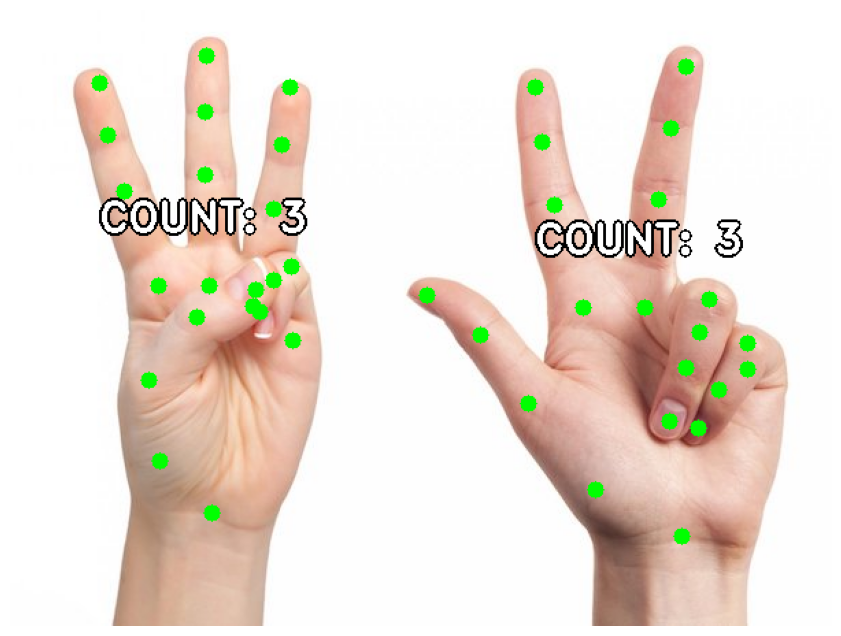

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
image_path = 'hand_gestures.jpg'
try:
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape
    # 1. Setup Detector
    base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
    options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=5)
    detector = vision.HandLandmarker.create_from_options(options)
    # 2. Run AI
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = detector.detect(mp_image)
    if result.hand_landmarks:
        for idx, landmarks in enumerate(result.hand_landmarks):
            # --- FINGER COUNTING LOGIC ---
            up_count = 0
            if landmarks[8].y < landmarks[6].y: up_count += 1
            if landmarks[12].y < landmarks[10].y: up_count += 1
            if landmarks[16].y < landmarks[14].y: up_count += 1
            if landmarks[20].y < landmarks[18].y: up_count += 1
            if landmarks[4].x < landmarks[3].x: up_count += 1
            # 1. Draw Landmarks
            for lm in landmarks:
                cx, cy = int(lm.x * w), int(lm.y * h)
                cv2.circle(img_rgb, (cx, cy), 6, (0, 255, 0), -1)
            # 2. FIXED TEXT PLACEMENT:
            text_x = int(landmarks[9].x * w) - 80
            text_y = int(landmarks[9].y * h) - 40 # Placed safely above the knuckle
            label = f"COUNT: {up_count}"
            cv2.putText(img_rgb, label, (text_x, text_y), cv2.FONT_HERSHEY_DUPLEX, 1.0, (0,0,0), 5)
            cv2.putText(img_rgb, label, (text_x, text_y), cv2.FONT_HERSHEY_DUPLEX, 1.0, (255,255,255), 2)
        print(f"✅ SUCCESS: {len(result.hand_landmarks)} hands labeled correctly.")
    else:
        print("❌ Hand not detected.")
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"❌ Error: {e}")